# Experiment: Figure 3 Circuit Neural Replay Examples

This notebook reconstructs the two example DDM trials used in Figure 3 and replays one local circuit trial per condition to expose neural dynamics without storing `r_E` or `r_B` for the full dataset.

It does three things:
- loads the saved two-condition Figure 3 DDM run
- reconstructs the exact example DDM noise realization needed to drive the local replay
- replays the corresponding circuit dynamics locally and plots `r_E` and `r_B`


In [8]:
from __future__ import annotations

import json
import runpy
from pathlib import Path

_NOTEBOOK_SETUP = None
for candidate in [Path.cwd().resolve(), *Path.cwd().resolve().parents]:
    helper = candidate / 'figures_code' / 'notebook_setup.py'
    if helper.exists():
        _NOTEBOOK_SETUP = runpy.run_path(str(helper))
        break
if _NOTEBOOK_SETUP is None:
    raise RuntimeError('Could not locate figures_code/notebook_setup.py')

import matplotlib.pyplot as plt
import numpy as np

from CANN_DDM_model_rate_based import CANN_DDM_model
from rate_model_core.accumulator_simulation import (
    _build_circuit_baseline_params,
    prepare_circuit_target_diffusion_calibration,
)

%config InlineBackend.figure_format = 'retina'

REPO_ROOT = _NOTEBOOK_SETUP['REPO_ROOT']
REPO_ROOT


PosixPath('/projectnb/ecog-eeg/cyw6/CANN_DDM_rate_model')

## Run Path And Replay Defaults

This notebook is pinned to the finished `fig3_cddm_two_condition_n3000` run. Update only this cell if the run root changes.


In [83]:
RUN_ROOT = REPO_ROOT / 'results' / 'figure3' / 'fig3_cddm_two_condition_n3000'
DATASET_PATH = RUN_ROOT / 'dataset.npz'
CONFIG_PATH = RUN_ROOT / 'config.json'


DATASET_PATH


PosixPath('/projectnb/ecog-eeg/cyw6/CANN_DDM_rate_model/results/figure3/fig3_cddm_two_condition_n3000/dataset.npz')

## Helpers

The helpers below keep the replay deterministic:
- load the saved Figure 3 dataset
- pick the same example trials as the DDM notebook
- reconstruct the DDM realization needed to regenerate the example drive
- replay one local circuit trial with monitors for `r_E` and `r_B`


In [89]:
def load_fig3_dataset(dataset_path: Path, config_path: Path) -> dict:
    dataset_path = Path(dataset_path)
    config_path = Path(config_path)
    if not dataset_path.exists():
        raise FileNotFoundError(f'Dataset not found: {dataset_path}')
    if not config_path.exists():
        raise FileNotFoundError(f'Config not found: {config_path}')

    with np.load(dataset_path, allow_pickle=False) as data:
        metadata = json.loads(str(data['metadata_json'].item()))
        x_traj = np.asarray(data['x_traj'], dtype=float) if 'x_traj' in data.files else None
        if x_traj is None:
            raise RuntimeError('This Figure 3 dataset does not contain x_traj.')
        return {
            'dataset_path': dataset_path,
            'config_path': config_path,
            'config': json.loads(config_path.read_text()),
            'metadata': metadata,
            'condition_labels': list(metadata['condition_labels']),
            'condition_seeds': [int(seed) for seed in metadata.get('condition_seeds', [])],
            'drift_rates': np.asarray(metadata['condition_drift_rates'], dtype=float),
            'noise_scales': np.asarray(metadata['condition_noise_scales'], dtype=float),
            'num_trials_per_condition': np.asarray(metadata['condition_num_trials'], dtype=int),
            't_start_ms': int(json.loads(config_path.read_text())['t_start']),
            'dt_ddm_ms': float(json.loads(config_path.read_text())['dt_ddm']),
            'dur_ms': int(json.loads(config_path.read_text())['dur']),
            'max_time_ms': int(json.loads(config_path.read_text())['max_time']),
            'x0': float(json.loads(config_path.read_text())['x0']),
            'boundary': float(json.loads(config_path.read_text())['boundary']),
            'choice': np.asarray(data['choice']),
            'hit_boundary': np.asarray(data['hit_boundary'], dtype=bool),
            'rt_ms': np.asarray(data['rt_ms'], dtype=float),
            'final_x': np.asarray(data['final_x'], dtype=float),
            'time_ms': np.asarray(data['time_ms'], dtype=float),
            'x_traj': x_traj,
        }


def finite_rt_mask(rt_ms: np.ndarray) -> np.ndarray:
    rt_ms = np.asarray(rt_ms, dtype=float)
    return np.isfinite(rt_ms) & (rt_ms > 0.0)


def correct_choice_value(drift_rate: float) -> int:
    return 1 if float(drift_rate) >= 0.0 else -1


def condition_descriptor(raw: dict, condition_index: int) -> str:
    label = raw['condition_labels'][condition_index]
    v = float(raw['drift_rates'][condition_index])
    c = float(raw['noise_scales'][condition_index])
    return f"{label} (v={v:.1f}, c={c:.1f})"


def choose_median_correct_trial(raw: dict, condition_index: int) -> int:
    choice = raw['choice'][condition_index]
    rt_ms = raw['rt_ms'][condition_index]
    correct_choice = correct_choice_value(raw['drift_rates'][condition_index])
    correct_indices = np.flatnonzero((choice == correct_choice) & finite_rt_mask(rt_ms))
    if correct_indices.size == 0:
        raise ValueError(f'No correct trials available for condition index {condition_index}')
    ordered = correct_indices[np.argsort(rt_ms[correct_indices], kind='stable')]
    return int(ordered[len(ordered) // 2])


def get_hit_index(hit_trace: np.ndarray) -> int | None:
    hit_indices = np.flatnonzero(np.asarray(hit_trace, dtype=bool))
    if hit_indices.size == 0:
        return None
    return int(hit_indices[0])


def reconstruct_example_ddm_trial(raw: dict, condition_index: int, trial_index: int) -> dict:
    drift_rate = float(raw['drift_rates'][condition_index])
    noise_scale = float(raw['noise_scales'][condition_index])
    condition_seed = int(raw['condition_seeds'][condition_index])
    num_trials = int(raw['num_trials_per_condition'][condition_index])
    dt_ddm_ms = int(round(float(raw['dt_ddm_ms'])))
    dt_s = float(raw['dt_ddm_ms']) * 1e-3
    t_start_ms = int(raw['t_start_ms'])
    dur_ms = int(raw['dur_ms'])
    max_time_ms = int(raw['max_time_ms'])
    x0 = float(raw['x0'])
    boundary = float(raw['boundary'])

    step_starts = np.arange(0, max_time_ms, dt_ddm_ms, dtype=int)
    rng = np.random.default_rng(condition_seed)
    x_curr = np.full(num_trials, x0, dtype=float)
    hit_boundary = np.zeros(num_trials, dtype=bool)
    choice = np.zeros(num_trials, dtype=np.int8)
    rt_ms = np.full(num_trials, np.nan, dtype=float)

    step_normals = np.zeros(step_starts.size, dtype=float)

    for step_index, start in enumerate(step_starts):
        if start < t_start_ms:
            continue

        drift_increment = drift_rate * dt_s if start < dur_ms else 0.0
        normals = rng.standard_normal(num_trials)
        step_normals[step_index] = float(normals[trial_index])
        increments = drift_increment + noise_scale * np.sqrt(dt_s) * normals

        active_trials = ~hit_boundary
        if np.any(active_trials):
            x_curr[active_trials] += increments[active_trials]
            right_hits = active_trials & (x_curr >= boundary)
            left_hits = active_trials & (x_curr <= 0.0)
            newly_hit = right_hits | left_hits

            x_curr[right_hits] = boundary
            x_curr[left_hits] = 0.0
            choice[right_hits] = 1
            choice[left_hits] = -1
            hit_boundary[newly_hit] = True
            rt_ms[newly_hit] = float(start - t_start_ms)

    dW_all = np.zeros(max_time_ms, dtype=float)
    for step_index, start in enumerate(step_starts):
        if start < t_start_ms or start >= dur_ms:
            continue
        dW_all[start] = np.sqrt(dt_s) * step_normals[step_index]


    return {
        'condition_index': int(condition_index),
        'trial_index': int(trial_index),
        'condition_label': raw['condition_labels'][condition_index],
        'condition_seed': condition_seed,
        'drift_rate': drift_rate,
        'noise_scale': noise_scale,
        'num_trials': num_trials,
        'dt_ddm_ms': dt_ddm_ms,
        'dt_s': dt_s,
        't_start_ms': t_start_ms,
        'dur_ms': dur_ms,
        'max_time_ms': max_time_ms,
        'x0': x0,
        'boundary': boundary,
        'time_ms': np.asarray(raw['time_ms'], dtype=float),
        'ddm_x': np.asarray(raw['x_traj'][condition_index, trial_index], dtype=float),
        'rt_ms': float(raw['rt_ms'][condition_index, trial_index]),
        'choice': int(raw['choice'][condition_index, trial_index]),
        'step_starts_ms': step_starts,
        'step_normals': step_normals,
        'dW_all': dW_all,
    }


def derive_circuit_trial_seed(condition_seed: int, num_trials: int, trial_index: int) -> int:
    child_sequences = np.random.SeedSequence(int(condition_seed)).spawn(int(num_trials))
    return int(child_sequences[int(trial_index)].generate_state(1)[0])


def prepare_shared_circuit_calibration(raw: dict) -> dict:
    return prepare_circuit_target_diffusion_calibration(
        dt_ddm=float(raw['dt_ddm_ms']),
        t_start=int(raw['t_start_ms']),
        dur=int(raw['dur_ms']),
        max_time=int(raw['max_time_ms']),
        seed=int(raw['config']['seed']),
    )


def build_circuit_replay_from_example(example_trial: dict, calibration: dict, monitors: list[str] | None = None) -> dict:
    monitors = ['x_E', 'x_B', 'theta_E', 'theta_B', 'r_E', 'r_B', 'hit_boundary'] if monitors is None else list(monitors)
    trial_seed = derive_circuit_trial_seed(
        example_trial['condition_seed'],
        example_trial['num_trials'],
        example_trial['trial_index'],
    )
    params = _build_circuit_baseline_params(
        coherence=1.0,
        drift_gain=float(example_trial['drift_rate']),
        noise_scale=float(example_trial['noise_scale']),
        dt_ddm=float(example_trial['dt_ddm_ms']),
        t_start=int(example_trial['t_start_ms']),
        dur=int(example_trial['dur_ms']),
        max_time=int(example_trial['max_time_ms']),
        seed=int(trial_seed),
        kappa=float(calibration['kappa']),
        x0=float(example_trial['x0']),
        boundary=float(example_trial['boundary']),
    )
    model = CANN_DDM_model(CANN_params=params)

    dt_ddm_ms = int(example_trial['dt_ddm_ms'])
    v_drift_steps = np.zeros(example_trial['step_starts_ms'].size, dtype=float)
    v_noise_steps = np.zeros(example_trial['step_starts_ms'].size, dtype=float)
    for step_index, start in enumerate(example_trial['step_starts_ms']):
        if start < example_trial['t_start_ms'] or start >= example_trial['dur_ms']:
            continue
        dW = float(example_trial['dW_all'][start])
        v_drift_steps[step_index] = (
            float(example_trial['drift_rate']) * float(example_trial['dt_s'])
            / (float(model.drive_x_speed_unit) * float(dt_ddm_ms))
        )
        v_noise_steps[step_index] = (
            float(example_trial['noise_scale']) * dW
            / (float(model.drive_x_speed_unit) * float(dt_ddm_ms))
        )

    model.dW_all = np.asarray(example_trial['dW_all'], dtype=float)
    model.v_drift_all = model.expand_decision_step_values(example_trial['max_time_ms'], float(example_trial['dt_ddm_ms']), v_drift_steps)
    model.v_noise_all = model.expand_decision_step_values(example_trial['max_time_ms'], float(example_trial['dt_ddm_ms']), v_noise_steps)
    model.v_drive_all = model.v_drift_all + model.v_noise_all
    model.x_traj = model.get_x_traj_continuous(
        example_trial['t_start_ms'],
        example_trial['dur_ms'],
        example_trial['drift_rate'],
        example_trial['noise_scale'],
        float(example_trial['dt_ddm_ms']),
        example_trial['x0'],
        model.dW_all,
        example_trial['boundary'],
    )

    runner = model.build_runner(mon_vars=monitors, progress_bar=False, dt=TRACE_DT_MS)
    runner.run(int(example_trial['max_time_ms']))

    x_E = np.asarray(runner.mon.x_E).reshape(-1)
    x_B = np.asarray(runner.mon.x_B).reshape(-1)
    theta_E = np.asarray(runner.mon.theta_E).reshape(-1)
    theta_B = np.asarray(runner.mon.theta_B).reshape(-1)
    r_E = np.asarray(runner.mon.r_E)
    r_B = np.asarray(runner.mon.r_B)
    hit_boundary = np.asarray(runner.mon.hit_boundary).reshape(-1).astype(bool)
    first_hit_index = get_hit_index(hit_boundary)
    if first_hit_index is None:
        first_hit_index = len(x_E) - 1

    return {
        'model': model,
        'trial_seed': int(trial_seed),
        'time_ms': np.arange(len(x_E), dtype=float) * float(TRACE_DT_MS),
        'x_E': x_E,
        'x_B': x_B,
        'theta_E': theta_E,
        'theta_B': theta_B,
        'r_E': r_E,
        'r_B': r_B,
        'hit_boundary': hit_boundary,
        'first_hit_index': int(first_hit_index),
        'first_hit_time_ms': float(first_hit_index * TRACE_DT_MS),
    }


def select_representative_neurons(replay: dict, num_neurons: int | None = None) -> dict:
    if num_neurons is None:
        num_neurons = int(NUM_REPRESENTATIVE_NEURONS)
    model = replay['model']
    hit_index = max(1, int(replay['first_hit_index']))
    theta_path = np.asarray(replay['theta_E'][: hit_index + 1], dtype=float)
    sampled_theta = np.quantile(theta_path, q=np.asarray(NEURON_QUANTILES, dtype=float))

    ordered_indices: list[int] = []
    for theta in sampled_theta:
        idx = int(np.round(float(model.pos_to_idx(theta)))) % int(model.num_E)
        if idx not in ordered_indices:
            ordered_indices.append(idx)

    anchor = ordered_indices[-1] if ordered_indices else int(np.round(float(model.pos_to_idx(theta_path[-1])))) % int(model.num_E)
    radius = 1
    while len(ordered_indices) < int(num_neurons):
        for candidate in ((anchor - radius) % int(model.num_E), (anchor + radius) % int(model.num_E)):
            if candidate not in ordered_indices:
                ordered_indices.append(int(candidate))
            if len(ordered_indices) >= int(num_neurons):
                break
        radius += 1

    ordered_indices = ordered_indices[: int(num_neurons)]
    preferred_x = []
    for idx in ordered_indices:
        theta = float(model.idx_to_pos(float(idx)))
        preferred_x.append(float(model.pos_to_evidence(theta, model.gamma_E)))

    return {
        'edge_indices': np.asarray(ordered_indices, dtype=int),
        'bump_indices': np.asarray(ordered_indices, dtype=int),
        'preferred_x': np.asarray(preferred_x, dtype=float),
    }


def plot_neural_replay_examples(example_trials: list[dict], circuit_replays: list[dict], neuron_sets: list[dict]) -> tuple[plt.Figure, np.ndarray]:
    fig, axes = plt.subplots(
        2,
        len(example_trials),
        figsize=(6.0, 6.0),
        sharex='col',
        constrained_layout=True,
    )
    if len(example_trials) == 1:
        axes = np.asarray(axes)[:, None]

    edge_ymax = 0.0
    bump_ymax = 0.0

    for column, (example_trial, replay, neuron_set) in enumerate(zip(example_trials, circuit_replays, neuron_sets)):
        replay_time_ms = np.asarray(replay['time_ms'], dtype=float)
        hit_end = int(replay['first_hit_index']) + 1
        neuron_alphas = np.linspace(NEURON_ALPHAS[0], NEURON_ALPHAS[-1], len(neuron_set['edge_indices']))

        ax_edge = axes[0, column]
        ax_bump = axes[1, column]

        for alpha, neuron_index in zip(neuron_alphas, neuron_set['edge_indices']):
            ax_edge.plot(
                replay_time_ms[:hit_end],
                replay['r_E'][:hit_end, int(neuron_index)],
                color=EDGE_COLOR,
                alpha=float(alpha),
                linewidth=1.6,
            )
        edge_ymax = max(edge_ymax, float(np.max(replay['r_E'][:hit_end, neuron_set['edge_indices']])))

        for alpha, neuron_index in zip(neuron_alphas, neuron_set['bump_indices']):
            ax_bump.plot(
                replay_time_ms[:hit_end],
                replay['r_B'][:hit_end, int(neuron_index)],
                color=BUMP_COLOR,
                alpha=float(alpha),
                linewidth=1.6,
            )
        bump_ymax = max(bump_ymax, float(np.max(replay['r_B'][:hit_end, neuron_set['bump_indices']])))

        for ax in (ax_edge, ax_bump):
            ax.set_xlim(0.0, float(PLOT_X_MAX_MS))
            ax.spines['top'].set_visible(False)
            ax.spines['right'].set_visible(False)
            ax.margins(x=0.0, y=0.0)

    edge_ylim = 1.0
    bump_ylim = 0.5
    x_ticks = [0.0, float(PLOT_X_MAX_MS)]
    for column in range(axes.shape[1]):
        axes[0, column].set_ylim(0.0, edge_ylim)
        axes[1, column].set_ylim(0.0, bump_ylim)
        axes[0, column].set_xticks(x_ticks)
        axes[1, column].set_xticks(x_ticks)
        axes[0, column].set_yticks([0, edge_ylim])
        axes[1, column].set_yticks([0, bump_ylim])
        axes[0, column].set_yticklabels([0, edge_ylim])
        for ax in (axes[0, column], axes[1, column]):
            ax.tick_params(axis='both', labelsize=TICK_FONTSIZE, length=0)

    return fig, axes


## Load The Saved Figure 3 Run

Load the finished Figure 3 DDM dataset and recover the two example trial indices used in the trajectory panel.


In [50]:
raw = load_fig3_dataset(DATASET_PATH, CONFIG_PATH)
example_trial_indices = tuple(
    choose_median_correct_trial(raw, condition_index)
    for condition_index in range(len(raw['condition_labels']))
)

print(f"example trial indices: {example_trial_indices}")


example trial indices: (2150, 261)


## Reconstruct The Example Drive

Rebuild the DDM noise realization needed to regenerate the two example drives for the local circuit replay.


In [71]:
example_trials = [[
    reconstruct_example_ddm_trial(raw, condition_index, trial_index)
    for condition_index, trial_index in enumerate(example_trial_indices)
][0]]


## Local Circuit Replay For The Two Examples

Only the two selected examples are replayed locally, so the notebook can expose `r_E` and `r_B` without creating a large saved dataset.


In [ ]:
shared_calibration = prepare_shared_circuit_calibration(raw)

In [ ]:
NUM_REPRESENTATIVE_NEURONS = 3
NEURON_QUANTILES = (0.75, 0.85, 0.9)

circuit_replays = [
    build_circuit_replay_from_example(example_trial, shared_calibration)
    for example_trial in example_trials
]
neuron_sets = [
    select_representative_neurons(replay, num_neurons=NUM_REPRESENTATIVE_NEURONS)
    for replay in circuit_replays
]


## Plot Neural Dynamics For The Two Replayed Examples

Top row: representative edge-population neuron traces.
Bottom row: representative bump-population neuron traces.


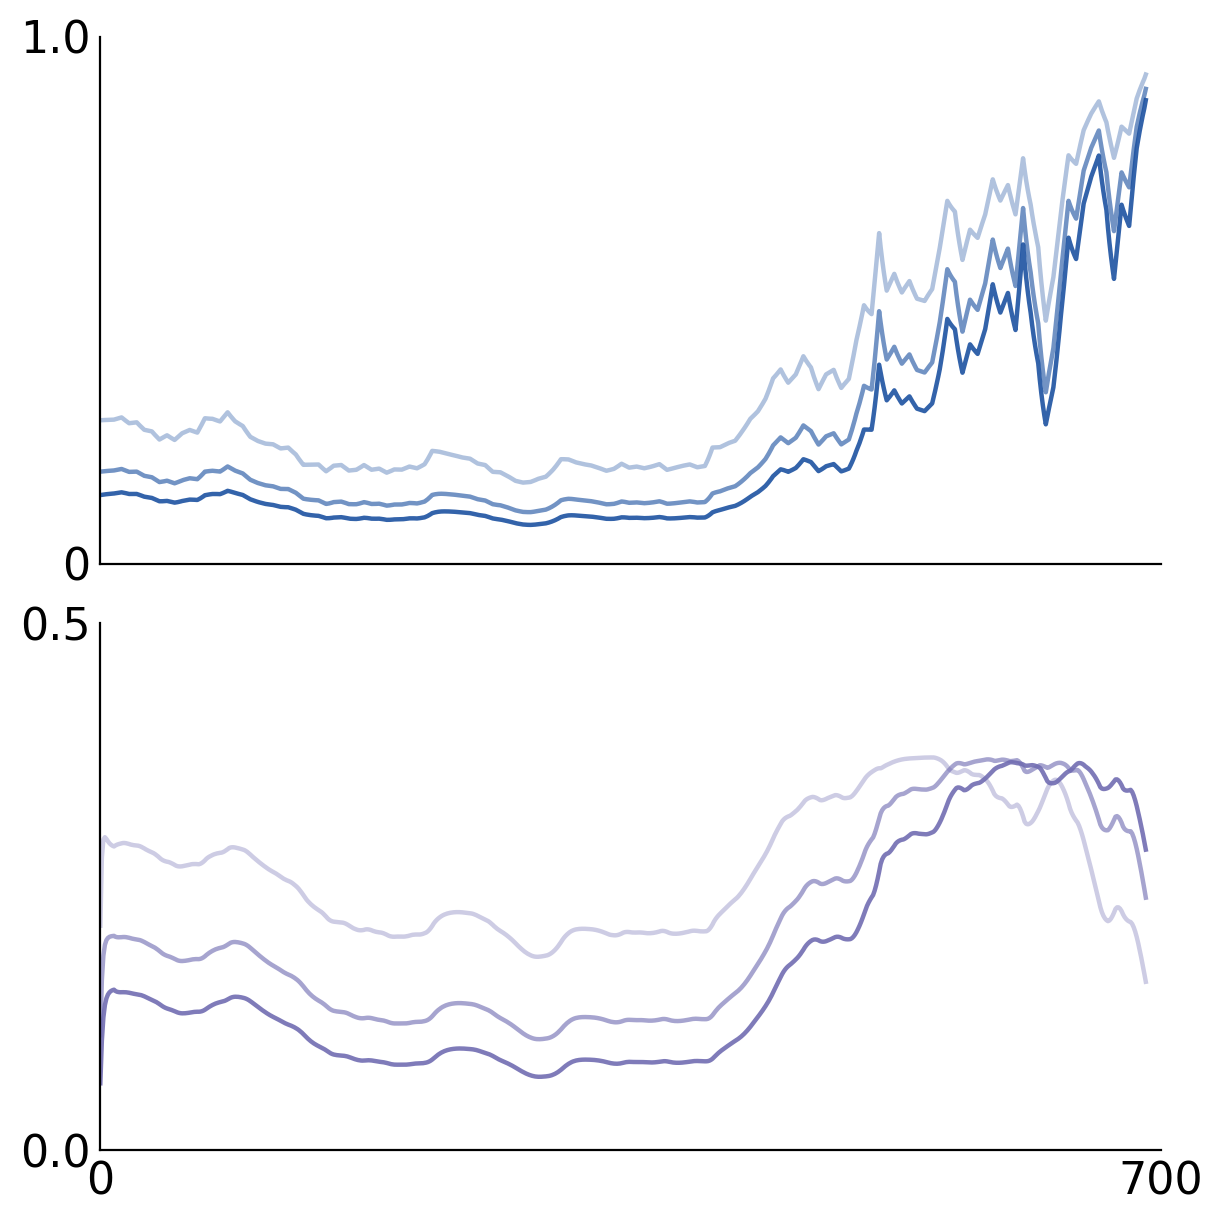

In [90]:
EDGE_COLOR = '#1d52a1'
BUMP_COLOR = '#716db2'
DDM_DV_COLOR = '#222222'
DDM_DV_ALPHA = 0.95
DDM_DV_LINEWIDTH = 2.2
CIRCUIT_DV_ALPHA = 0.9
CIRCUIT_DV_LINEWIDTH = 1.8
BOUNDARY_COLOR = '#444444'
PLOT_X_MAX_MS = 700.0
TICK_FONTSIZE = 16
fig, axes = plot_neural_replay_examples(example_trials, circuit_replays, neuron_sets)
plt.show()
